In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

In [57]:
df = pd.read_csv(r'C:\Users\Opeyemi\DataScience\Fraudulent-Transaction-Detection-for-Digital-Money-Transfer\data\nova_pay_combined.csv', thousands =',')

In [58]:
df.head()

,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,exchange_rate_src_to_dest,device_id,new_device,ip_address,ip_country,location_mismatch,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud
0,fee8542d-8ee6-4b0d-9671-c294dd08ed26,402cccc9-28de-45b3-9af7-cc5302aa1f93,2022-10-03 18:40:59.468549+00:00,US,USD,CAD,ATM,278.19,278.19,4.25,1.351351,9f292dcc-3297-4947-a260-6a1ef69041ff,False,221.78.171.180,US,False,0.123,standard,263,0.522,0,0.223,0,0,0.0,0
1,bfdb9fc1-27fe-4a85-b043-4d813d679259,67c2c6b3-ef0a-4777-a3f1-c84a851bb6ad,2022-10-03 20:39:38.468549+00:00,CA,CAD,MXN,web,208.51,154.29,4.24,12.758621,3a95b9f5-309f-4684-a46d-e2ff2435bf78,True,120.12.20.29,CA,False,0.569,standard,947,0.475,0,0.268,0,1,0.0,0
2,fc855034-3ea5-4993-9afa-b511d93fe5e8,6d0d9b27-fa26-45f8-93b1-2df29d182d9c,2022-10-03 23:02:43.468549+00:00,US,USD,CNY,mobile,160.33,160.33,2.70,7.142857,a4737752-9aac-43ed-9d8b-2ccdffc24052,False,223.96.181.93,US,False,0.437,enhanced,367,0.939,0,0.176,0,0,0.0,0
3,2cf8c08e-42ec-444d-a755-34b9a2a0a4ca,7bd5200c-5d19-44f0-9afe-8b339a05366b,2022-10-04 01:08:53.468549+00:00,US,USD,EUR,mobile,59.41,59.41,2.22,0.925926,6aeb85a3-5603-4221-896c-9e6882764f1a,False,186.228.15.74,US,False,0.594,standard,147,0.551,0,0.391,0,0,0.0,0
4,d907a74d-b426-438d-97eb-dbe911aca91c,70a93d26-8e3a-4179-900c-a4a7a74d08e5,2022-10-04 09:35:03.468549+00:00,US,USD,INR,mobile,200.96,200.96,3.61,83.333333,a5b9250e-dbe0-4c5f-a6e7-5492b7349402,False,11.82.47.62,US,False,0.121,enhanced,257,0.894,0,0.257,0,0,0.0,0


In [59]:
# checking unique values in  is_fraud
df.is_fraud.value_counts()

is_fraud
0    10403
1      997
Name: count, dtype: int64

In [60]:
# Class imbalance that the dataset is highly imbalanced, with only 0.5% of transactions being fraudulent.
#This will require careful handling during model training to avoid bias towards the majority class.

In [61]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 11400 entries, 0 to 11399
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   transaction_id             11400 non-null  str    
 1   customer_id                11400 non-null  str    
 2   timestamp                  11371 non-null  str    
 3   home_country               11400 non-null  str    
 4   source_currency            11400 non-null  str    
 5   dest_currency              11400 non-null  str    
 6   channel                    11400 non-null  str    
 7   amount_src                 11400 non-null  float64
 8   amount_usd                 11095 non-null  float64
 9   fee                        11105 non-null  float64
 10  exchange_rate_src_to_dest  11400 non-null  float64
 11  device_id                  11400 non-null  str    
 12  new_device                 11400 non-null  bool   
 13  ip_address                 11095 non-null  str    
 14  i

In [62]:
df.duplicated().sum()

np.int64(200)

In [63]:
df.drop_duplicates(subset=['transaction_id', 'customer_id', 'device_id', 'ip_address'],inplace=True)

In [64]:
df.drop(columns=['transaction_id', 'customer_id', 'device_id', 'ip_address'],inplace=True)

In [65]:
df.info()

<class 'pandas.DataFrame'>
Index: 11200 entries, 0 to 11399
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   timestamp                  11171 non-null  str    
 1   home_country               11200 non-null  str    
 2   source_currency            11200 non-null  str    
 3   dest_currency              11200 non-null  str    
 4   channel                    11200 non-null  str    
 5   amount_src                 11200 non-null  float64
 6   amount_usd                 10900 non-null  float64
 7   fee                        10910 non-null  float64
 8   exchange_rate_src_to_dest  11200 non-null  float64
 9   new_device                 11200 non-null  bool   
 10  ip_country                 10904 non-null  str    
 11  location_mismatch          11200 non-null  bool   
 12  ip_risk_score              11200 non-null  float64
 13  kyc_tier                   10905 non-null  str    
 14  accoun

In [66]:
null_columns = df.isnull().mean()* 100 > 0
null_columns[null_columns].index.tolist()

['timestamp',
 'amount_usd',
 'fee',
 'ip_country',
 'kyc_tier',
 'device_trust_score']

In [67]:
null_columns = df.isnull().mean()* 100 > 0
null_columns[null_columns == True]

timestamp             True
amount_usd            True
fee                   True
ip_country            True
kyc_tier              True
device_trust_score    True
dtype: bool

In [68]:
#describe categorial features
df.describe(include= 'str')

,timestamp,home_country,source_currency,dest_currency,channel,ip_country,kyc_tier
count,11171,11200,11200,11200,11200,10904,10905
unique,11141,7,3,9,12,9,14
top,0000-00-00T00:00:00Z,US,USD,NGN,mobile,US,standard
freq,21,7784,7875,1447,6242,6713,7780


In [69]:
#describe numerical features
df.describe()

,amount_src,amount_usd,fee,exchange_rate_src_to_dest,ip_risk_score,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud
count,11200.000000,10900.000000,10910.000000,11200.000000,11200.000000,11200.000000,10910.000000,11200.000000,11200.000000,11200.000000,11200.000000,11200.000000,11200.000000
mean,437.572747,451.710904,99.212001,167.453693,0.397541,392.848571,0.653238,0.049375,0.267653,0.463839,0.732411,0.045406,0.088839
std,1373.086218,1401.028359,952.526927,381.930143,0.271213,342.123998,0.273174,0.258388,0.143521,1.532671,1.970835,0.084876,0.284524
min,-9997.160000,7.230000,-1.000000,0.592000,0.004000,1.000000,-0.100000,0.000000,0.000000,-1.000000,0.000000,0.000000,0.000000
25%,90.715000,92.492500,2.380000,1.000000,0.209000,147.000000,0.515000,0.000000,0.169000,0.000000,0.000000,0.000000,0.000000
50%,158.980000,163.485000,3.500000,7.142857,0.325000,293.000000,0.654500,0.000000,0.223000,0.000000,0.000000,0.000000,0.000000
75%,295.042500,302.707500,5.560000,73.529412,0.488000,661.000000,0.894000,0.000000,0.391000,0.000000,0.000000,0.050000,0.000000
max,11942.890000,12498.570000,9999.990000,1388.888889,1.200000,1095.000000,0.999000,2.000000,0.900000,8.000000,11.000000,0.250000,1.000000


In [70]:
# 'coerce' is used to standardise to null values any entries that cannot be converted to datetime or numeric formats, which helps in identifying and handling invalid data during analysis.
df["timestamp"] = pd.to_datetime(df["timestamp"], errors='coerce')

df["amount_src"] = pd.to_numeric(df["amount_src"], errors='coerce')
df.info()

<class 'pandas.DataFrame'>
Index: 11200 entries, 0 to 11399
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype              
---  ------                     --------------  -----              
 0   timestamp                  11140 non-null  datetime64[us, UTC]
 1   home_country               11200 non-null  str                
 2   source_currency            11200 non-null  str                
 3   dest_currency              11200 non-null  str                
 4   channel                    11200 non-null  str                
 5   amount_src                 11200 non-null  float64            
 6   amount_usd                 10900 non-null  float64            
 7   fee                        10910 non-null  float64            
 8   exchange_rate_src_to_dest  11200 non-null  float64            
 9   new_device                 11200 non-null  bool               
 10  ip_country                 10904 non-null  str                
 11  location_mismatch 

In [71]:
# To identify and fix ammount that are non numeric
mask = pd.to_numeric(df['amount_src'], errors='coerce').isnull()
print(df['amount_src'][mask].value_counts())

Series([], Name: count, dtype: int64)


In [72]:
df[df['amount_src'].isnull()]

,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,exchange_rate_src_to_dest,new_device,ip_country,location_mismatch,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud


In [73]:
# inconsistent categorical variables
categorical_cols = df.select_dtypes(include='str').columns.tolist()
print(categorical_cols)

['home_country', 'source_currency', 'dest_currency', 'channel', 'ip_country', 'kyc_tier']


In [74]:
#To view dirty catergorical variables
for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(df[col].unique())
    print(df[col].value_counts())


--- home_country ---
<StringArray>
['US', 'CA', 'UK', ' UK  ', ' US  ', 'unknown', ' CA  ']
Length: 7, dtype: str
home_country
US         7784
UK         2091
CA         1205
 US          68
unknown      32
 UK          13
 CA           7
Name: count, dtype: int64

--- source_currency ---
<StringArray>
['USD', 'CAD', 'GBP']
Length: 3, dtype: str
source_currency
USD    7875
GBP    2111
CAD    1214
Name: count, dtype: int64

--- dest_currency ---
<StringArray>
['CAD', 'MXN', 'CNY', 'EUR', 'INR', 'GBP', 'PHP', 'NGN', 'USD']
Length: 9, dtype: str
dest_currency
NGN    1447
INR    1304
USD    1302
CNY    1297
PHP    1290
GBP    1273
CAD    1260
EUR    1177
MXN     850
Name: count, dtype: int64

--- channel ---
<StringArray>
[      'ATM',       'web',    'mobile',       'WEB',    ' web  ',    'MOBILE',
   'mobille',   'unknown', ' mobile  ',      'weeb',       'ATm',    ' ATM  ']
Length: 12, dtype: str
channel
mobile       6242
web          3674
ATM           989
mobille        59
 mobile   

In [75]:
for col in categorical_cols:
    df[col] = df[col].str.strip().str.lower()

In [76]:
# dictionary inside dictonary here ' typo_correction' is the main dictionary, 
# and it contains three nested dictionaries for the columns 'channel', 'ip_country', and 'kyc_tier'.
# Each nested dictionary maps incorrect or inconsistent values to their corrected forms. 
# For example, in the 'channel' column, 'weeb' is corrected to 'web', and 'mobille' is corrected to 'mobile'. 
# In the 'ip_country' column, 'nan' is corrected to 'unknown'. 
# In the 'kyc_tier' column, 'nan' is corrected to 'unknown', 'standrd' is corrected to 'standard', and 
# 'enhancd' is corrected to 'enhanced'. 
# This structure allows for organized and efficient correction of typos in the dataset.
typo_correction = {
'channel' : {'weeb':'web', 'mobille': 'mobile'},
'ip_country': {'nan': 'unknown'},
'kyc_tier' : {'nan': 'unknown', 'standrd':'standard', 'enhancd': 'enhanced' }
}

# explaining like i'm in college, this code iterates through each column specified in the 'typo_correction' 
# dictionary and applies the corrections defined in the nested dictionaries to the corresponding columns in the 
# DataFrame 'df'.
for col, corrections in typo_correction.items():
    df[col] = df[col].replace(corrections)

In [77]:
df.isnull().sum()

timestamp                     60
home_country                   0
source_currency                0
dest_currency                  0
channel                        0
amount_src                     0
amount_usd                   300
fee                          290
exchange_rate_src_to_dest      0
new_device                     0
ip_country                   296
location_mismatch              0
ip_risk_score                  0
kyc_tier                     295
account_age_days               0
device_trust_score           290
chargeback_history_count       0
risk_score_internal            0
txn_velocity_1h                0
txn_velocity_24h               0
corridor_risk                  0
is_fraud                       0
dtype: int64

In [78]:
df.head(15)

,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,exchange_rate_src_to_dest,new_device,ip_country,location_mismatch,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud
0,2022-10-03 18:40:59.468549+00:00,us,usd,cad,atm,278.19,278.19,4.25,1.351351,False,us,False,0.123,standard,263,0.522,0,0.223,0,0,0.00,0
1,2022-10-03 20:39:38.468549+00:00,ca,cad,mxn,web,208.51,154.29,4.24,12.758621,True,ca,False,0.569,standard,947,0.475,0,0.268,0,1,0.00,0
2,2022-10-03 23:02:43.468549+00:00,us,usd,cny,mobile,160.33,160.33,2.70,7.142857,False,us,False,0.437,enhanced,367,0.939,0,0.176,0,0,0.00,0
3,2022-10-04 01:08:53.468549+00:00,us,usd,eur,mobile,59.41,59.41,2.22,0.925926,False,us,False,0.594,standard,147,0.551,0,0.391,0,0,0.00,0
4,2022-10-04 09:35:03.468549+00:00,us,usd,inr,mobile,200.96,200.96,3.61,83.333333,False,us,False,0.121,enhanced,257,0.894,0,0.257,0,0,0.00,0
5,2022-10-04 12:09:59.468549+00:00,us,usd,gbp,mobile,526.90,526.90,8.75,0.800000,False,us,False,0.094,low,616,0.702,0,0.361,0,0,0.00,0
6,2022-10-04 12:37:41.468549+00:00,ca,cad,gbp,mobile,149.24,110.44,2.33,0.592000,False,ca,False,0.299,standard,947,0.625,0,0.268,0,0,0.00,0
7,2022-10-04 16:27:44.468549+00:00,ca,cad,inr,web,276.51,204.62,5.59,61.666667,False,ca,False,0.087,standard,1041,0.867,0,0.245,0,1,0.12,0
8,2022-10-04 21:00:36.468549+00:00,us,usd,eur,mobile,99.52,99.52,2.41,0.925926,False,us,False,0.182,enhanced,367,0.939,0,0.176,0,0,0.00,0
9,2022-10-04 21:20:42.468549+00:00,us,usd,php,web,302.55,302.55,5.26,58.823529,False,us,False,0.413,standard,1016,0.944,0,0.247,0,0,0.10,1


In [79]:
# i understand there 3 unique sources,  which eventually changed or denominated to amount_usd.
# write the equation, i expect ther will be 1 rate for each source to amount_usd
exchange_rates = df.groupby('amount_src')['amount_usd'].mean()
# this not correct, write another code to get the exchange rate for each source to amount_usd
exchange_rates = df[df['amount_usd'].notna()].groupby('source_currency').apply(lambda x: (x['amount_usd'] / x['amount_src']).mean()).to_dict()


In [80]:

exchange_rates

{'cad': 0.7226052713792916,
 'gbp': 1.2243263027658966,
 'usd': 0.9838204592901879}

In [81]:
df['source_currency'].value_counts()

source_currency
usd    7875
gbp    2111
cad    1214
Name: count, dtype: int64

In [82]:
# fill missing values in amount_usd using the exchange rates, 
# if amount_usd exists, keep it as is, 
# if not, calculate it using amount_src and the corresponding exchange rate for the source_currency.
df['amount_usd'] = df.apply(lambda row: row['amount_src'] * exchange_rates.get(row['source_currency'],1), axis=1)

In [83]:
# using grouped imputation to fill missing values in the 'fee' column based on the mean fee for each channel.
if " fee" in df.columns:
    if ' channel' in df.columns:
         df['fee'] = df.groupby('channel')['fee'].transform(lambda s:s.fillna(s.mean()))
df['fee'] = df['fee'].fillna(df['fee'].mean())

In [84]:
df.isnull().sum()

timestamp                     60
home_country                   0
source_currency                0
dest_currency                  0
channel                        0
amount_src                     0
amount_usd                     0
fee                            0
exchange_rate_src_to_dest      0
new_device                     0
ip_country                   296
location_mismatch              0
ip_risk_score                  0
kyc_tier                     295
account_age_days               0
device_trust_score           290
chargeback_history_count       0
risk_score_internal            0
txn_velocity_1h                0
txn_velocity_24h               0
corridor_risk                  0
is_fraud                       0
dtype: int64

In [85]:
# ip_country: fallback to home_country
if {'ip_country', 'home_country'}.issubset(df.columns):
    df['ip_country'] = df['ip_country'].fillna(df['home_country'])

In [86]:
# kyc_tier: fill with mode
# The cell missing kyc_tier
# find the most frequent kyc_tier(mode)
# if  mode is unavailable, defaults to 'standard'
# fills missing values with this mode/default
if 'kyc_tier' in df.columns:
    mode_kyc = df['kyc_tier'].mode().iloc[0] if not df['kyc_tier'].mode().empty else 'standard'
    df['kyc_tier'] = df['kyc_tier'].fillna(mode_kyc)

In [87]:
# The cell missing device_trust_score
# if  new_device and kyc_tier exist, fill missing score per group using the group median
# then fill any remaing missing score with the overall median
if 'device_trust_score' in df.columns:
    if{'new_device', 'kyc_tier'}.issubset(df.columns):
        df['device_trust_score'] = df.groupby(['new_device', 'kyc_tier'])['device_trust_score']\
            .transform(lambda s: s.fillna(s.median()))
    df['device_trust_score'] = df['device_trust_score'].fillna(df['device_trust_score'].median())

In [88]:
df.describe(include= 'all')

,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,exchange_rate_src_to_dest,new_device,ip_country,location_mismatch,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud
count,11140,11200,11200,11200,11200,11200.000000,11200.000000,11200.000000,11200.000000,11200,11200,11200,11200.000000,11200,11200.000000,11200.000000,11200.000000,11200.000000,11200.000000,11200.000000,11200.000000,11200.000000
unique,NaN,4,3,9,4,NaN,NaN,NaN,NaN,2,4,2,NaN,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,us,usd,ngn,mobile,NaN,NaN,NaN,NaN,False,us,False,NaN,standard,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,7852,7875,1447,6395,NaN,NaN,NaN,NaN,9864,6968,9375,NaN,8280,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,2024-05-02 16:55:49.276814+00:00,NaN,NaN,NaN,NaN,437.572747,435.348915,99.212001,167.453693,NaN,NaN,NaN,0.397541,NaN,392.848571,0.651994,0.049375,0.267653,0.463839,0.732411,0.045406,0.088839
min,2022-10-03 18:40:59.468549+00:00,NaN,NaN,NaN,NaN,-9997.160000,-9835.410543,-1.000000,0.592000,NaN,NaN,NaN,0.004000,NaN,1.000000,-0.100000,0.000000,0.000000,-1.000000,0.000000,0.000000,0.000000
25%,2023-08-14 08:19:50.468549+00:00,NaN,NaN,NaN,NaN,90.715000,89.269409,2.410000,1.000000,NaN,NaN,NaN,0.209000,NaN,147.000000,0.515000,0.000000,0.169000,0.000000,0.000000,0.000000,0.000000
50%,2024-05-07 14:05:38.968549+00:00,NaN,NaN,NaN,NaN,158.980000,158.623856,3.580000,7.142857,NaN,NaN,NaN,0.325000,NaN,293.000000,0.625000,0.000000,0.223000,0.000000,0.000000,0.000000,0.000000
75%,2025-01-29 12:42:56.468549+00:00,NaN,NaN,NaN,NaN,295.042500,295.733971,5.902500,73.529412,NaN,NaN,NaN,0.488000,NaN,661.000000,0.894000,0.000000,0.391000,0.000000,0.000000,0.050000,0.000000
max,2025-12-16 00:13:41.468549+00:00,NaN,NaN,NaN,NaN,11942.890000,12241.867296,9999.990000,1388.888889,NaN,NaN,NaN,1.200000,NaN,1095.000000,0.999000,2.000000,0.900000,8.000000,11.000000,0.250000,1.000000


In [89]:
df[df['amount_src'].isnull()]

,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,exchange_rate_src_to_dest,new_device,ip_country,location_mismatch,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud


In [90]:
mask = pd.to_numeric(df['amount_src'], errors='coerce').isnull()
print(df['amount_src'][mask].value_counts())

#Check what dfnew was throwing error

Series([], Name: count, dtype: int64)


In [91]:
# Fill timestamp nulls using forward fill then backward fill
df = df.sort_values('timestamp').reset_index(drop=True)
df['timestamp'] = df['timestamp'].ffill().bfill()

In [92]:
df.isnull().sum()

timestamp                    0
home_country                 0
source_currency              0
dest_currency                0
channel                      0
amount_src                   0
amount_usd                   0
fee                          0
exchange_rate_src_to_dest    0
new_device                   0
ip_country                   0
location_mismatch            0
ip_risk_score                0
kyc_tier                     0
account_age_days             0
device_trust_score           0
chargeback_history_count     0
risk_score_internal          0
txn_velocity_1h              0
txn_velocity_24h             0
corridor_risk                0
is_fraud                     0
dtype: int64

In [93]:
df['hour_of_day'] = df['timestamp'].dt.hour
df['day_of_week'] = df['timestamp'].dt.day_name()
df['is_weekend'] = df['timestamp'].dt.weekday >= 5
df['is_night'] = df['hour_of_day'].isin([0,1,2,3,4,5])

print(df[['hour_of_day', 'day_of_week', 'is_weekend', 'is_night']].head())

   hour_of_day day_of_week  is_weekend  is_night
0           18      Monday       False     False
1           20      Monday       False     False
2           23      Monday       False     False
3            1     Tuesday       False      True
4            9     Tuesday       False     False


In [94]:
df['corridor'] = df['source_currency'] + '_to_' + df['dest_currency']

In [95]:
df.groupby('corridor')['is_fraud'].mean().sort_values(ascending=False)

corridor
cad_to_inr    0.604520
gbp_to_ngn    0.392283
usd_to_mxn    0.264344
gbp_to_eur    0.147059
usd_to_ngn    0.132411
cad_to_ngn    0.120968
usd_to_php    0.119276
gbp_to_cny    0.099206
gbp_to_usd    0.091667
gbp_to_gbp    0.087866
gbp_to_mxn    0.085837
cad_to_mxn    0.085271
gbp_to_inr    0.084034
cad_to_eur    0.079365
cad_to_php    0.078947
cad_to_cad    0.074324
gbp_to_php    0.071730
gbp_to_cad    0.066667
cad_to_gbp    0.065041
cad_to_usd    0.052239
cad_to_cny    0.050360
usd_to_cny    0.038631
usd_to_gbp    0.035126
usd_to_eur    0.029508
usd_to_cad    0.027057
usd_to_inr    0.021372
usd_to_usd    0.017241
Name: is_fraud, dtype: float64

In [96]:
# Fraud rate: night vs day
df.groupby('is_night')['is_fraud'].mean()

is_night
False    0.080608
True     0.112943
Name: is_fraud, dtype: float64

In [97]:
df.groupby('is_weekend')['is_fraud'].mean()

is_weekend
False    0.088875
True     0.088746
Name: is_fraud, dtype: float64

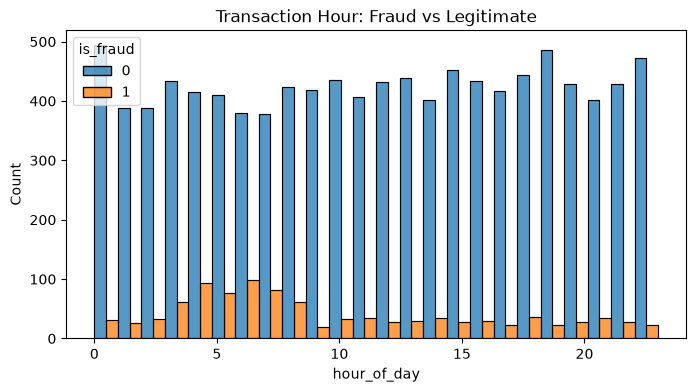

In [98]:
plt.figure(figsize=(8, 4))
sns.histplot(data=df, x='hour_of_day', hue='is_fraud', multiple='dodge', bins=24)
plt.title('Transaction Hour: Fraud vs Legitimate')
plt.show()

In [99]:
#Frauds happens throughout the day, its activity is elevated in the early hours, remains at steady level throughout the rmaing hous of the day

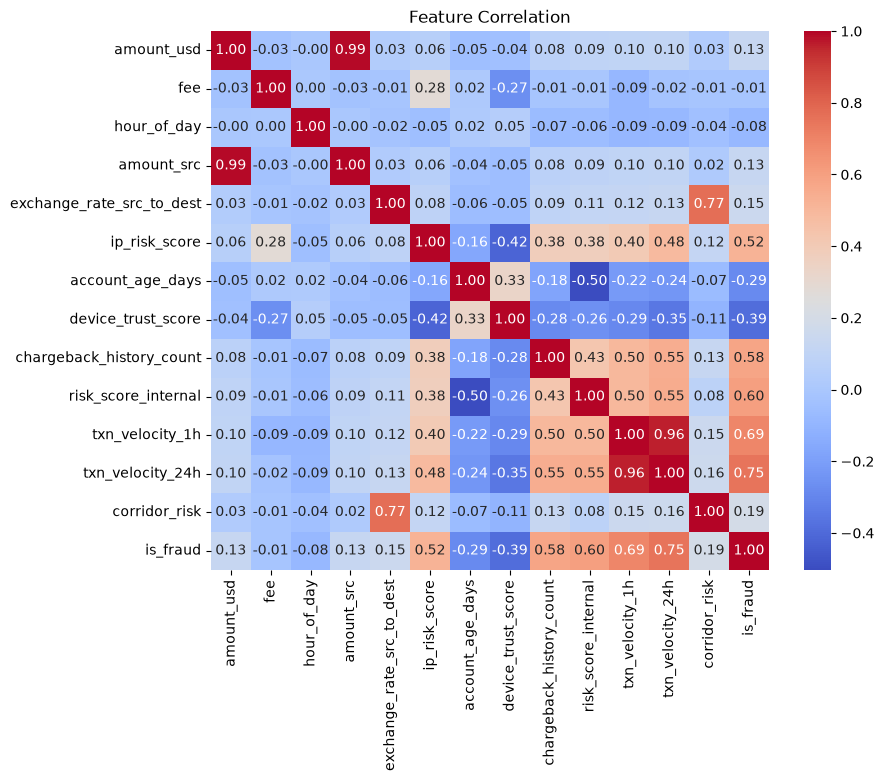

In [100]:
# correllation heat map
numeric_cols = ['amount_usd', 'fee', 'hour_of_day', 'amount_src', 'exchange_rate_src_to_dest', 
                'ip_risk_score', 'account_age_days','device_trust_score', 'chargeback_history_count', 
                'risk_score_internal', 'txn_velocity_1h', 'txn_velocity_24h', 'corridor_risk', 'is_fraud']

plt.figure(figsize=(9, 7))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation')
plt.show()

In [101]:
# txn_velocity_24h0.75High transaction frequency in 24hrs = strong fraud signal
# txn_velocity_1h0.69Same but within 1 hour — rapid fire transactions = red flag
# risk_score_internal0.60Internal risk scoring is working well
# chargeback_history_count0.58Past chargebacks predict future fraud
# ip_risk_score0.52Risky IP address = fraud signal
# device_trust_score-0.39Trusted device = less fraud (negative is good here)
# account_age_days-0.29Older accounts = less fraud

In [102]:
# extract time based features
df['hour_of_day'] = df['timestamp'].dt.hour
df['day_of_week'] = df['timestamp'].dt.dayofweek
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)

print('time features created')
print(df[['timestamp', 'hour_of_day', 'day_of_week', 'is_weekend']].head())
print('\nHour of Day Distribution:')
print(df['hour_of_day'].value_counts().sort_index())

time features created
                         timestamp  hour_of_day  day_of_week  is_weekend
0 2022-10-03 18:40:59.468549+00:00           18            0           0
1 2022-10-03 20:39:38.468549+00:00           20            0           0
2 2022-10-03 23:02:43.468549+00:00           23            0           0
3 2022-10-04 01:08:53.468549+00:00            1            1           0
4 2022-10-04 09:35:03.468549+00:00            9            1           0

Hour of Day Distribution:
hour_of_day
0     525
1     414
2     421
3     495
4     509
5     487
6     478
7     460
8     485
9     438
10    469
11    441
12    460
13    468
14    436
15    480
16    464
17    439
18    481
19    509
20    456
21    435
22    456
23    494
Name: count, dtype: int64


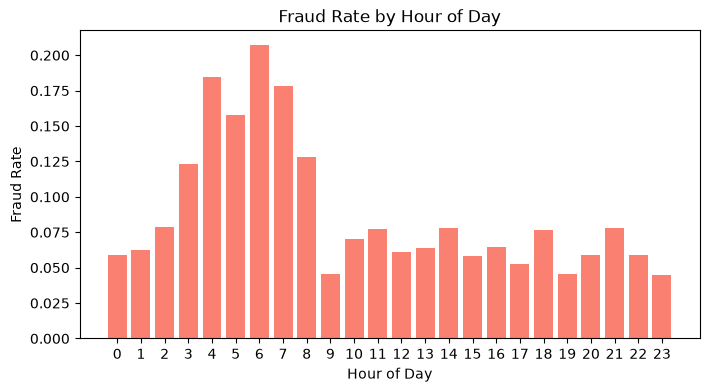

In [103]:
#fraudrate by hour
fraud_by_hour = df.groupby('hour_of_day')['is_fraud'].mean()
plt.figure(figsize=(8, 4))
plt.bar(fraud_by_hour.index, fraud_by_hour.values, color='salmon')
plt.title('Fraud Rate by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Fraud Rate')
plt.xticks(range(0, 24))
plt.show()

age_bucket
<0-30d      0.354603
31-90d      0.435597
91-180d     0.025075
181-365d    0.016846
> 1year     0.010606
Name: is_fraud, dtype: float64


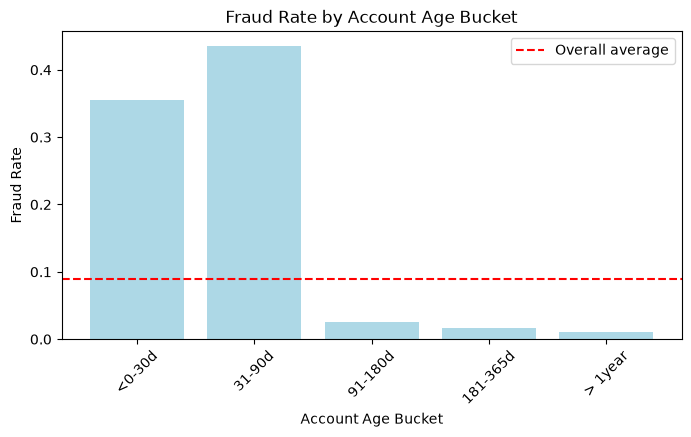

In [104]:
# fraud rateby account age date
df['age_bucket'] = pd.cut(df['account_age_days'], bins=[0, 30, 90, 180, 365, 2000],\
     labels=['<0-30d', '31-90d', '91-180d', '181-365d', '> 1year'])

fraud_by_age = df.groupby('age_bucket')['is_fraud'].mean()
print(fraud_by_age)

plt.figure(figsize=(8, 4))
plt.bar(fraud_by_age.index, fraud_by_age.values, color='lightblue')
plt.title('Fraud Rate by Account Age Bucket')
plt.axhline(df['is_fraud'].mean(), color='red', linestyle='--', label='Overall average')
plt.xlabel('Account Age Bucket')
plt.ylabel('Fraud Rate')
plt.xticks(rotation=45)
plt.legend()
plt.show()

txn_velocity_1h
-1    0.020000
 0    0.018093
 1    0.000000
 2    0.000000
 3    0.832700
 4    0.831967
 5    0.809524
 6    0.704142
 7    0.690265
 8    0.471910
Name: is_fraud, dtype: float64


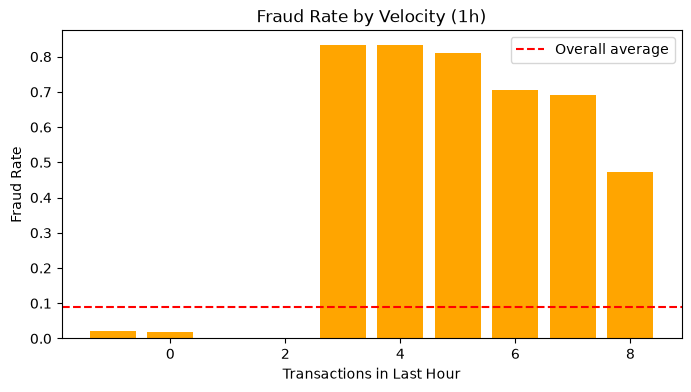

In [105]:
#fraud rate by velocity (transaction in the last hour)
fraud_by_velocity = df.groupby('txn_velocity_1h')['is_fraud'].mean()
print(fraud_by_velocity)

plt.figure(figsize=(8, 4))
plt.bar(fraud_by_velocity.index, fraud_by_velocity.values, color='orange')
plt.title('Fraud Rate by Velocity (1h)')
plt.xlabel('Transactions in Last Hour')
plt.ylabel('Fraud Rate')
plt.axhline(df['is_fraud'].mean(), color='red', linestyle='--', label='Overall average')
plt.legend()
plt.show()

amount_bucket
<$100       0.017925
$100-500    0.062462
$500-1k     0.293532
$1k-2k      0.683398
$2k-5k      0.386282
> $5k       0.156250
Name: is_fraud, dtype: float64


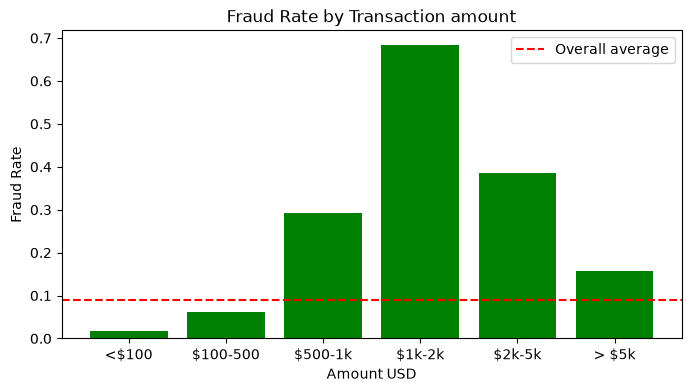

In [106]:
#fraud rate by amount  buckets
df['amount_bucket'] = pd.cut(df['amount_usd'], bins=[0, 100, 500, 1000, 2000, 10000, np.inf],\
     labels=['<$100', '$100-500', '$500-1k', '$1k-2k', '$2k-5k', '> $5k'])

fraud_by_amount = df.groupby('amount_bucket')['is_fraud'].mean()
print(fraud_by_amount)
plt.figure(figsize=(8, 4))
plt.bar(fraud_by_amount.index, fraud_by_amount.values, color='green')
plt.title('Fraud Rate by Transaction amount')
plt.xlabel('Amount USD')
plt.ylabel('Fraud Rate')
plt.axhline(df['is_fraud'].mean(), color='red', linestyle='--', label='Overall average')
plt.legend()
plt.show()

ip_risk_bucket
Low (0-0.3)                 0.015513
(0.3-0.5)                   0.022248
(0.5-0.7)                   0.029712
 (0.7-0.8)                  0.200000
 Very Critical (0.8-1.0)    0.620496
Name: is_fraud, dtype: float64


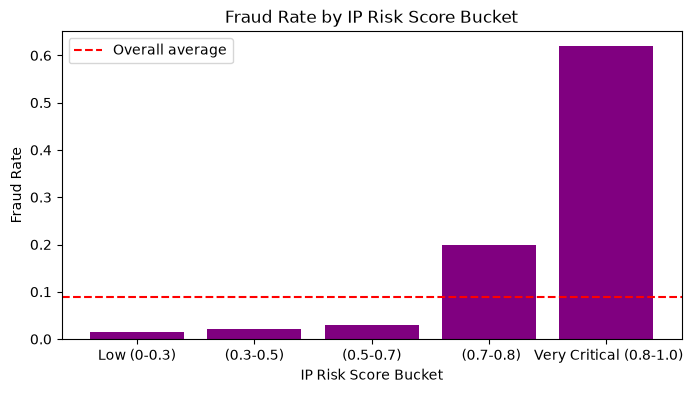

In [107]:
df['ip_risk_bucket'] = pd.cut(df['ip_risk_score'], bins=[0, 0.3, 0.5, 0.7, 0.8, 1.0],\
        labels=['Low (0-0.3)', '(0.3-0.5)', '(0.5-0.7)', ' (0.7-0.8)', ' Very Critical (0.8-1.0)'])
fraud_by_ip_risk = df.groupby('ip_risk_bucket')['is_fraud'].mean()
print(fraud_by_ip_risk)

plt.figure(figsize=(8, 4))
plt.bar(fraud_by_ip_risk.index, fraud_by_ip_risk.values, color='purple')
plt.title('Fraud Rate by IP Risk Score Bucket')
plt.xlabel('IP Risk Score Bucket')
plt.ylabel('Fraud Rate')
plt.axhline(df['is_fraud'].mean(), color='red', linestyle='--', label='Overall average')
plt.legend()
plt.show()

device_trust_bucket
Low<0.3)      0.848611
(0.3-0.5)     0.111049
(0.5-0.7)     0.021049
 (0.7-0.8)    0.015723
 High>0.8     0.022250
Name: is_fraud, dtype: float64


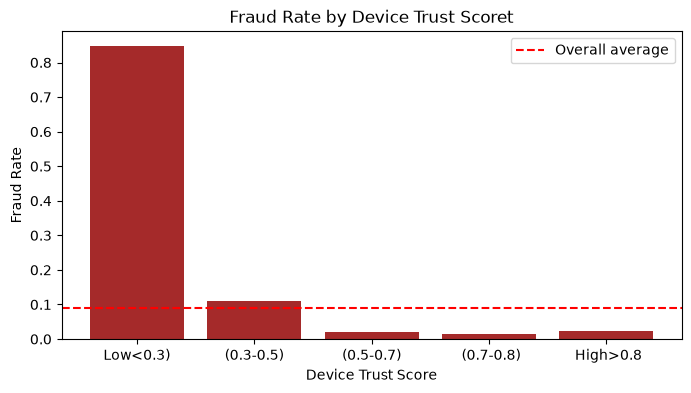

In [108]:
# fraud rate by deice trust score bucket
df['device_trust_score'].describe()
df['device_trust_bucket'] = pd.cut(df['device_trust_score'], bins=[0, 0.3, 0.5, 0.7, 0.8, 1.0],\
        labels=['Low<0.3)', '(0.3-0.5)', '(0.5-0.7)', ' (0.7-0.8)', ' High>0.8'])
fraud_by_device_trust = df.groupby('device_trust_bucket')['is_fraud'].mean()
print(fraud_by_device_trust)

plt.figure(figsize=(8, 4))
plt.bar(fraud_by_device_trust.index, fraud_by_device_trust.values, color='brown')
plt.title('Fraud Rate by Device Trust Scoret')
plt.xlabel('Device Trust Score')
plt.ylabel('Fraud Rate')
plt.axhline(df['is_fraud'].mean(), color='red', linestyle='--', label='Overall average')
plt.legend()
plt.show()

In [109]:
#based on our analysis, create threshold-based features
df['night_hours'] = ((df['hour_of_day'] >= 3) & (df['hour_of_day'] < 7)).astype(int)
df['account_very_new'] = (df['account_age_days'] < 30).astype(int)
df['account_new'] = ((df['account_age_days'] >= 30) & (df['account_age_days'] < 90)).astype(int)
df['velocity_burst'] = (df['txn_velocity_1h'] >= 3).astype(int)
df['amount_high'] = (df['amount_usd'] > 2000).astype(int)
df['ip_risk_high'] = (df['ip_risk_score'] > 0.8).astype(int)
df['device_low'] = (df['device_trust_score'] < 0.3).astype(int)

print('features created')
print(df[['night_hours', 'account_very_new', 'account_new', 'velocity_burst',\
     'amount_high', 'ip_risk_high', 'device_low']].describe())

features created
        night_hours  account_very_new   account_new  velocity_burst  \
count  11200.000000      11200.000000  11200.000000    11200.000000   
mean       0.175804          0.170179      0.030893        0.095268   
std        0.380670          0.375806      0.173035        0.293598   
min        0.000000          0.000000      0.000000        0.000000   
25%        0.000000          0.000000      0.000000        0.000000   
50%        0.000000          0.000000      0.000000        0.000000   
75%        0.000000          0.000000      0.000000        0.000000   
max        1.000000          1.000000      1.000000        1.000000   

        amount_high  ip_risk_high    device_low  
count  11200.000000  11200.000000  11200.000000  
mean       0.027589      0.129375      0.081875  
std        0.163800      0.335630      0.274186  
min        0.000000      0.000000      0.000000  
25%        0.000000      0.000000      0.000000  
50%        0.000000      0.000000      0.00

In [112]:
df.to_csv(r'C:\Users\Opeyemi\DataScience\Fraudulent-Transaction-Detection-for-Digital-Money-Transfer/data/cleaned_transactionsV1.csv', index=False)

In [113]:
print(df.columns.tolist())

['timestamp', 'home_country', 'source_currency', 'dest_currency', 'channel', 'amount_src', 'amount_usd', 'fee', 'exchange_rate_src_to_dest', 'new_device', 'ip_country', 'location_mismatch', 'ip_risk_score', 'kyc_tier', 'account_age_days', 'device_trust_score', 'chargeback_history_count', 'risk_score_internal', 'txn_velocity_1h', 'txn_velocity_24h', 'corridor_risk', 'is_fraud', 'hour_of_day', 'day_of_week', 'is_weekend', 'is_night', 'corridor', 'age_bucket', 'amount_bucket', 'ip_risk_bucket', 'device_trust_bucket', 'night_hours', 'account_very_new', 'account_new', 'velocity_burst', 'amount_high', 'ip_risk_high', 'device_low']
